In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier, plot_tree

from xgboost import XGBClassifier, plot_importance

import sklearn.metrics as metrics

In [17]:
data = pd.read_csv('HR_capstone_dataset.csv')

# pulled in data from the dataset csv into a panda dataframe

In [18]:
data.head(10)

# observing the first few fields of each column

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


In [19]:
data.duplicated().sum()

# check for duplicate rows

np.int64(3008)

In [20]:
data[data.duplicated()]

# viewing duplicates

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [21]:
data = data.drop_duplicates()

# drop duplicates from the dataset

In [22]:
data = data.rename(columns={'Department':'department','average_montly_hours':'average_monthly_hours', 'time_spend_company':'years_at_company', 'Work_accident':'work_accident'})

# renaming columns to match the schema

In [23]:
data.info()

# observing counts of data and data types

<class 'pandas.core.frame.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     11991 non-null  float64
 1   last_evaluation        11991 non-null  float64
 2   number_project         11991 non-null  int64  
 3   average_monthly_hours  11991 non-null  int64  
 4   years_at_company       11991 non-null  int64  
 5   work_accident          11991 non-null  int64  
 6   left                   11991 non-null  int64  
 7   promotion_last_5years  11991 non-null  int64  
 8   department             11991 non-null  object 
 9   salary                 11991 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.0+ MB


Proceeding to perform EDA

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, '2'),
  Text(1, 0, '3'),
  Text(2, 0, '4'),
  Text(3, 0, '5'),
  Text(4, 0, '6'),
  Text(5, 0, '7'),
  Text(6, 0, '8'),
  Text(7, 0, '10')])

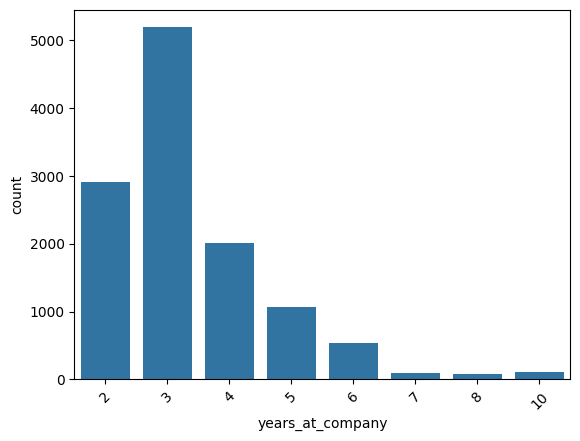

In [24]:
sns.countplot(data, x='years_at_company')
plt.xticks(rotation=45)

# most employees have 2-4 years at the company - peaks at 3 years 
# seems to be a critical period for retention

# presented in bar chart for visibility

([0, 1], [Text(0, 0, '0'), Text(1, 0, '1')])

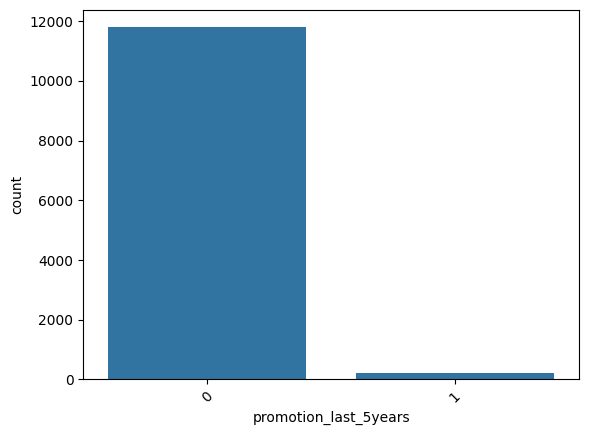

In [25]:
sns.countplot(data, x='promotion_last_5years')
plt.xticks(rotation=45)

# not the highest ranked feature, but most employees are not being promoted within 5 years

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'sales'),
  Text(1, 0, 'accounting'),
  Text(2, 0, 'hr'),
  Text(3, 0, 'technical'),
  Text(4, 0, 'support'),
  Text(5, 0, 'management'),
  Text(6, 0, 'IT'),
  Text(7, 0, 'product_mng'),
  Text(8, 0, 'marketing'),
  Text(9, 0, 'RandD')])

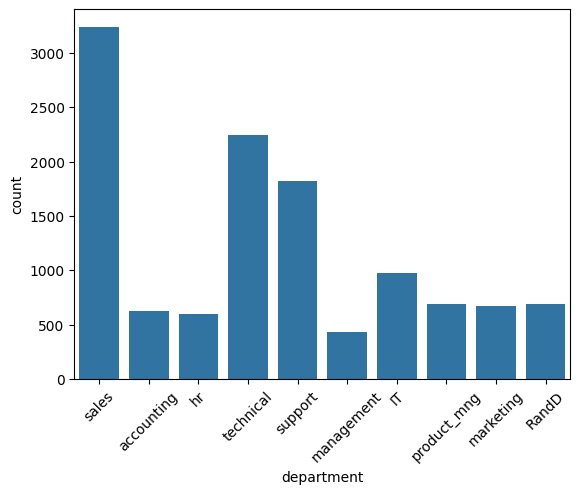

In [26]:
sns.countplot(data, x='department')
plt.xticks(rotation=45)

# Output count of employees in each department in a barchart

# Sales is the biggest group, followed by technical and support. 
# IT is the last stand out


<Axes: xlabel='years_at_company'>

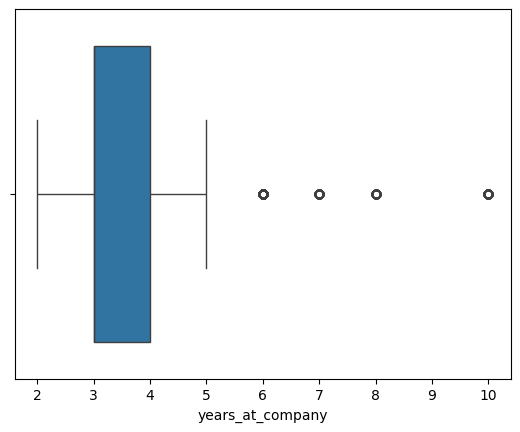

In [27]:
sns.boxplot(data, x='years_at_company')

# Created boxplot to look at company years outliers (not much different from bar chart)

([0, 1, 2], [Text(0, 0, 'low'), Text(1, 0, 'medium'), Text(2, 0, 'high')])

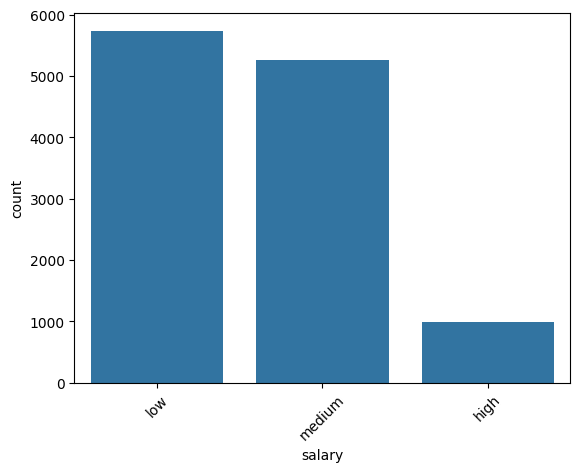

In [28]:
sns.countplot(data, x='salary')
plt.xticks(rotation=45)

# looking at salary category breakout - high paid employees is the exception

<Axes: xlabel='left', ylabel='years_at_company'>

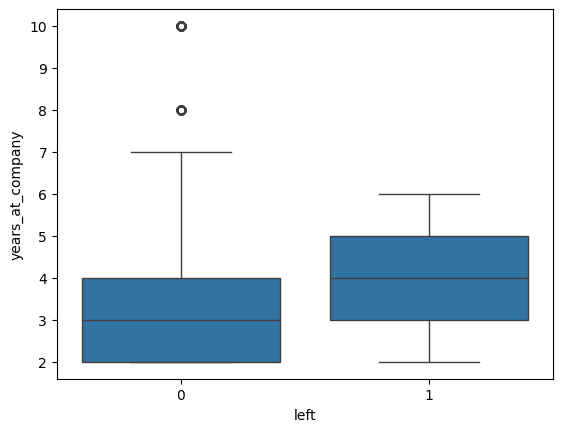

In [29]:
sns.boxplot(data, x='left', y='years_at_company')

# Boxplot examing relationship between those who left and years at company

# There is a transition range visible at 3 years, though 
#   there are outliers who have not left
# Employee trend seems to be making their decision at the 3-5 year range

# Beyond this are outliers, there are few employees remaining after 5 years

In [ ]:
#sns.boxplot(data, x='left', y='salary_level')

# salary level does not seem to make a big difference

ValueError: Could not interpret value `salary_level` for `y`. An entry with this name does not appear in `data`.

In [ ]:
#data[['salary_level', 'salary']].value_counts()

salary_level  salary
1             low       5740
2             medium    5261
0             high       990
Name: count, dtype: int64

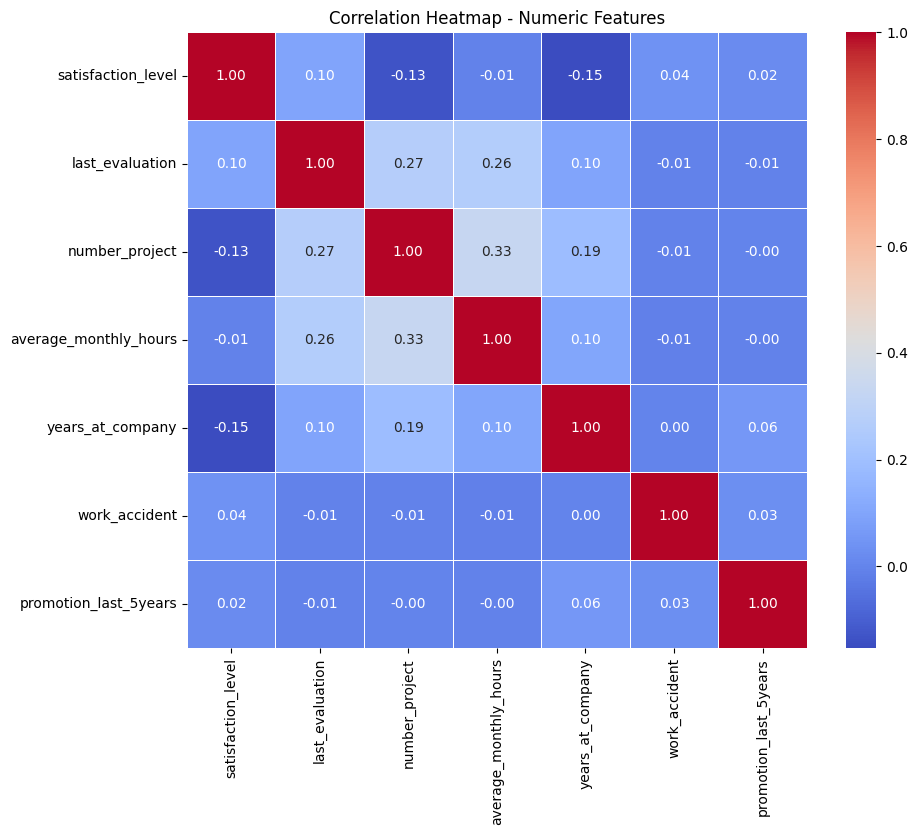

In [31]:
columns = [
    'satisfaction_level',
    'last_evaluation',
    'number_project',
    'average_monthly_hours',
    'years_at_company',
    'work_accident',
    'promotion_last_5years',
    #'left'
]
plt.figure(figsize=(10,8))
corr = data[columns].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap - Numeric Features')
plt.show()

# Heatmap shows key indicator groupings
    # Number of projects and average monthly hours
    # Number of projects and last evaluation

# satisfaction level seems overly correlated with "left"

In [32]:
dept_salary = data.groupby('department')['left'].mean()
dept_salary.head(10).sort_values(ascending=False)

# broke out the mean left for each department

department
hr             0.188020
accounting     0.175523
technical      0.173797
support        0.171334
sales          0.169805
marketing      0.166419
IT             0.161885
product_mng    0.160350
RandD          0.122478
management     0.119266
Name: left, dtype: float64

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'IT'),
  Text(1, 0, 'RandD'),
  Text(2, 0, 'accounting'),
  Text(3, 0, 'hr'),
  Text(4, 0, 'management'),
  Text(5, 0, 'marketing'),
  Text(6, 0, 'product_mng'),
  Text(7, 0, 'sales'),
  Text(8, 0, 'support'),
  Text(9, 0, 'technical')])

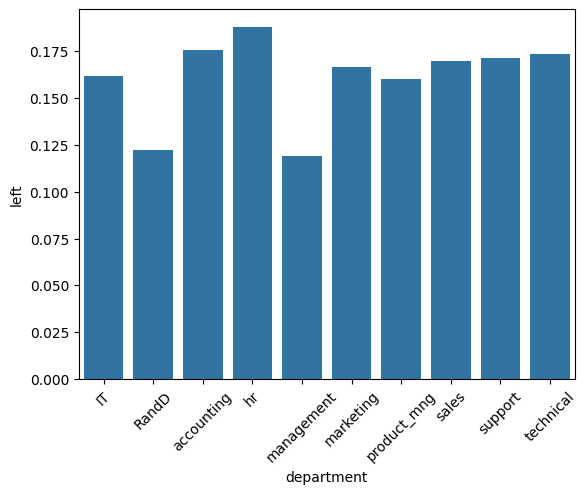

In [33]:

sns.barplot(dept_salary)
plt.xticks(rotation=45)

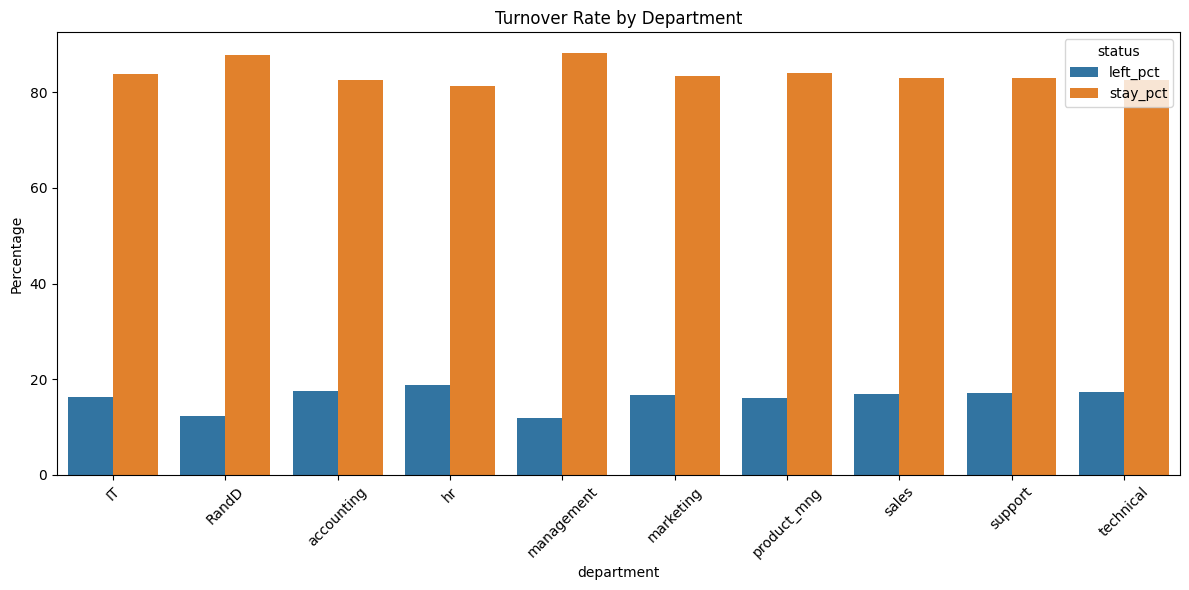

In [34]:
grouped = data.groupby('department')['left'].mean().reset_index()
grouped['left_pct'] = grouped['left'] * 100
grouped['stay_pct'] = 100 - grouped['left_pct']

plot_df = grouped.melt(id_vars='department',
                       value_vars=['left_pct', 'stay_pct'],
                       var_name='status',
                       value_name='percentage')


plt.figure(figsize=(12,6))
sns.barplot(data=plot_df, x='department', y='percentage',
            hue='status', dodge=True)


plt.ylabel('Percentage')
plt.title('Turnover Rate by Department')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# grouped bar chart showing turnover rate - not much difference among departments

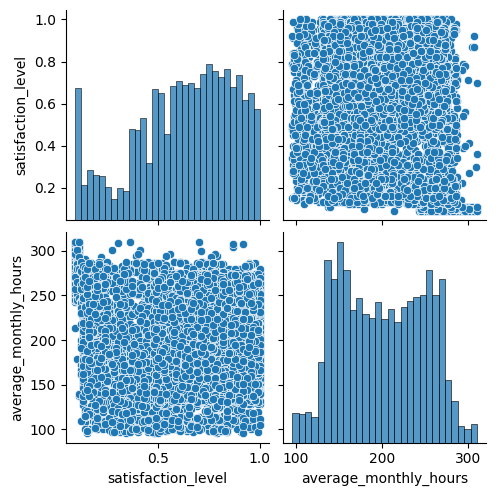

In [35]:
sns.pairplot(data[['satisfaction_level','average_monthly_hours']])

In [36]:
# Attempted using cat.codes

data['department_code'] = data['department'].astype('category').cat.codes
data['salary_level'] = data['salary'].astype('category').cat.codes

In [37]:
data = pd.get_dummies(data=data, columns=['department', 'salary'])

# got dummies for department and salary

In [38]:
# Checking final data info


data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   satisfaction_level      11991 non-null  float64
 1   last_evaluation         11991 non-null  float64
 2   number_project          11991 non-null  int64  
 3   average_monthly_hours   11991 non-null  int64  
 4   years_at_company        11991 non-null  int64  
 5   work_accident           11991 non-null  int64  
 6   left                    11991 non-null  int64  
 7   promotion_last_5years   11991 non-null  int64  
 8   department_code         11991 non-null  int8   
 9   salary_level            11991 non-null  int8   
 10  department_IT           11991 non-null  bool   
 11  department_RandD        11991 non-null  bool   
 12  department_accounting   11991 non-null  bool   
 13  department_hr           11991 non-null  bool   
 14  department_management   11991 non-null  boo

Building Model

In [39]:
X = data.drop(columns=['left', 'average_monthly_hours'])
y = data[['left']]

# created model variables

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# created test set

In [41]:
clf = LogisticRegression(class_weight='balanced', max_iter=1000).fit(X_train, y_train,)

y_pred = clf.predict(X_test)

# built logisticregression model and collected predictions

c:\Users\force\.virtualenvs\Exercises-ze98Lg8I\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [42]:
print(f'Coefficient: {clf.coef_}, Intercept: {clf.intercept_}')

Coefficient: [[-4.3696008   1.48757201 -0.36373885  0.67017646 -1.32785228 -1.47302044
   0.00830108  0.41495826  0.00971693 -0.4138706   0.04534293  0.13905209
  -0.33254561  0.08570217  0.0105547   0.04699185  0.04300355  0.00885574
  -0.91689084  0.70443091 -0.14473633]], Intercept: [-0.42585868]


<Axes: xlabel='satisfaction_level', ylabel='left'>

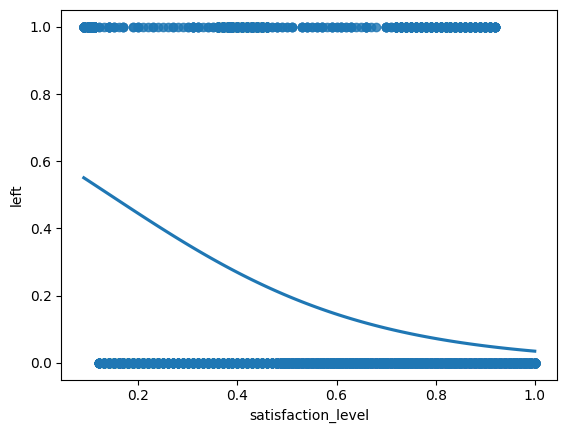

In [43]:
sns.regplot(x='satisfaction_level', y='left', data=data, logistic=True, ci=None)

# built regplot to observe satisfaction level relationship to left (low correlation)

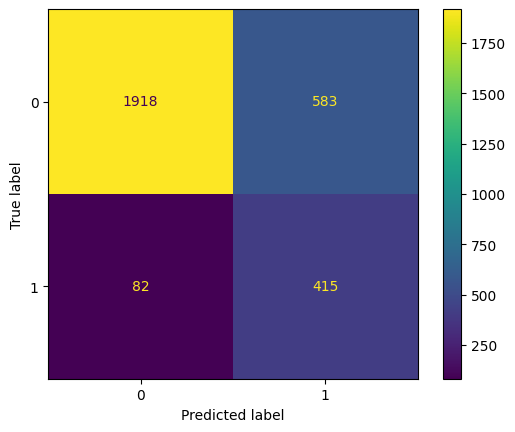

In [44]:
cm = metrics.confusion_matrix(y_test, y_pred, labels = clf.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = clf.classes_)
disp.plot()

# matrix shows high level to predict whether they stay
# not great at predicting leaving - high level of false positives

In [45]:
# balancing the y-value

left_count = y_train.sum()
stay_count = (len(y_train) - left_count).sum()
scale = (stay_count/left_count).sum()

# balanced due to left positive count being low

In [46]:
print(scale, type(scale))

5.019410977242303 <class 'numpy.float64'>


In [47]:
xgb = XGBClassifier(objective='binary:logistic', scale_pos_weight=scale,
                    eval_metric='logloss',
                    tree_method='hist', random_state=0)

# using xgb classifier to see if more models will give better results

In [48]:
cv_params = {
    'max_depth': [4, 6, 8],
    'min_child_weight':[2,3,4],
    'learning_rate':[0.05, 0.1],
    'n_estimators':[200, 400],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

scoring = {'accuracy':'accuracy',
           'precision': 'precision',
           'recall':'recall',
           'f1':'f1'
           }

xgb_cv = GridSearchCV(xgb, cv_params, scoring=scoring, cv=5, refit='f1')

# setup parameters - performing gridsearchCV

In [49]:
xgb_cv.fit(X_train, y_train)

# building model

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'colsample_bytree': [0.8],
                         'learning_rate': [0.05, 0.1], 'max_depth': [4, 6, 8],
                         'min_child_weight': [2, 3, 4],
                         'n_estimators': [200, 400], 'subsample': [0.8]},
             refit='f1',
             scoring={'accuracy': 'accuracy', 'f1': 'f1',
                      'precision': 'precision', 'recall': 'recall'})

In [61]:
path = r'C:\Users\force\Programming\Data Science\Exercises\Coursera Data Python\Capstone Project\\'

In [62]:
import pickle

In [ ]:
#with open(path +"SalifortMotorsProject.pickle", 'wb') as to_write:
#    pickle.dump(xgb_cv, to_write)

# Pickled model

In [66]:
with open(path +"SalifortMotorsProject.pickle", 'rb') as to_read:
    xgb_cv = pickle.load(to_read)

In [67]:
xgb_cv.best_score_

# best score is excellent (.93)

np.float64(0.9314535916027703)

In [51]:
y_preds2 = xgb_cv.predict(X_test)

# testing model

In [52]:
print(f'F1 Final: {f1_score(y_test, y_preds2)}\n\
    Recall: {recall_score(y_test, y_preds2)}\n\
    Precision: {precision_score(y_test, y_preds2)}\n\
    Accuracy: {accuracy_score(y_test, y_preds2)}'
    )

# great results for the test

F1 Final: 0.9194699286442406
    Recall: 0.9074446680080482
    Precision: 0.9318181818181818
    Accuracy: 0.9736490993995998


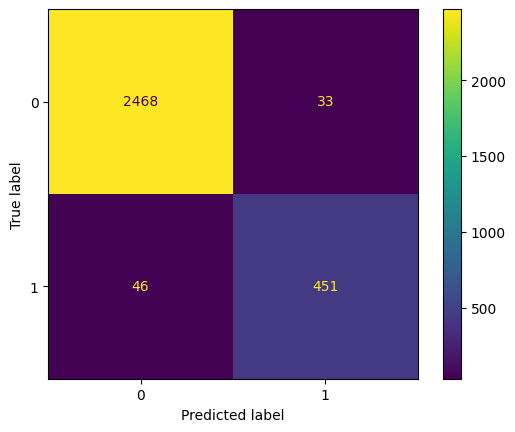

In [53]:
cm2 = metrics.confusion_matrix(y_test, y_preds2, labels=xgb_cv.classes_)
metrics.ConfusionMatrixDisplay(cm2, display_labels=xgb_cv.classes_).plot()

# This model performed much better - not overfitted

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

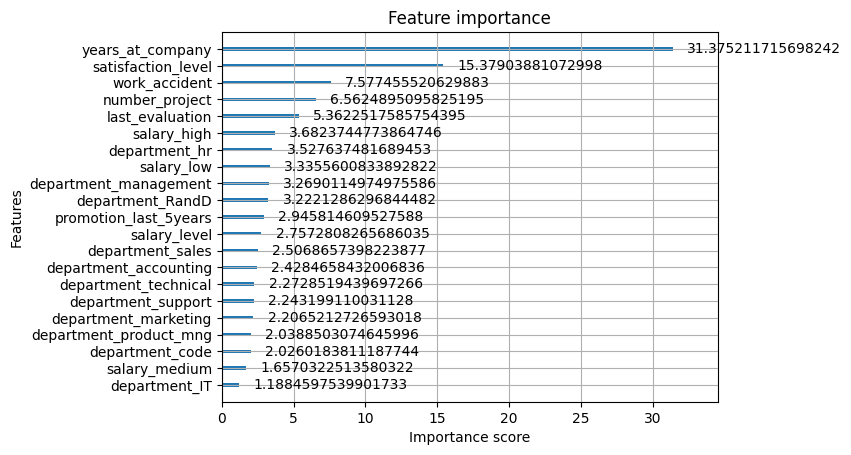

In [54]:
plot_importance(xgb_cv.best_estimator_, importance_type='gain')

Workers are leaving or appear to be thinking at leaving at the 3 year mark - clear fall off of employees, and employees retained beyond 5 years are outliers.

There is strong correlation between years at company, satisfaction level, the number of projects and the last evaluation
- The number of projects and last evaluation seem to tie into satisfaction level surveys
    - Number of projects and average monthly hours
    - Number of projects and last evaluation

In [55]:
data.groupby('left')[['number_project', 'average_monthly_hours']].mean()

# means is not useful for just reviewing "left"

,number_project,average_monthly_hours
left,,
0,3.786800,198.94270
1,3.883476,208.16223


In [56]:
data.groupby(pd.cut(data['number_project'], bins=5))['satisfaction_level'].mean()

# better visibility - indicates increased projects ties to low satisfaction level


C:\Users\force\AppData\Local\Temp\ipykernel_19360\230012620.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(pd.cut(data['number_project'], bins=5))['satisfaction_level'].mean()


number_project
(1.995, 3.0]    0.630396
(3.0, 4.0]      0.694280
(4.0, 5.0]      0.671155
(5.0, 6.0]      0.314673
(6.0, 7.0]      0.116690
Name: satisfaction_level, dtype: float64

In [57]:
data.groupby(pd.cut(data['average_monthly_hours'], bins=5))['satisfaction_level'].mean()

# there is a sweet spot for higher satisfaction - drops on a curve around 181-267 hours

C:\Users\force\AppData\Local\Temp\ipykernel_19360\771296496.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(pd.cut(data['average_monthly_hours'], bins=5))['satisfaction_level'].mean()


average_monthly_hours
(95.786, 138.8]    0.559062
(138.8, 181.6]     0.627280
(181.6, 224.4]     0.677053
(224.4, 267.2]     0.665778
(267.2, 310.0]     0.476244
Name: satisfaction_level, dtype: float64

In [58]:
data.groupby(pd.cut(data['last_evaluation'], bins=5))['satisfaction_level'].mean()

# may want to review employees with low evaluations and low satisfaction. lower than .488
# is correlated with low satisfaction level

C:\Users\force\AppData\Local\Temp\ipykernel_19360\995085619.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(pd.cut(data['last_evaluation'], bins=5))['satisfaction_level'].mean()


last_evaluation
(0.359, 0.488]    0.509173
(0.488, 0.616]    0.620525
(0.616, 0.744]    0.666827
(0.744, 0.872]    0.628519
(0.872, 1.0]      0.647685
Name: satisfaction_level, dtype: float64

In [60]:
data.groupby(pd.cut(data['work_accident'], bins=5))['satisfaction_level'].mean()

C:\Users\force\AppData\Local\Temp\ipykernel_19360\869220093.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(pd.cut(data['work_accident'], bins=5))['satisfaction_level'].mean()


work_accident
(-0.001, 0.2]    0.625546
(0.2, 0.4]            NaN
(0.4, 0.6]            NaN
(0.6, 0.8]            NaN
(0.8, 1.0]       0.652200
Name: satisfaction_level, dtype: float64

C:\Users\force\AppData\Local\Temp\ipykernel_19360\3024892229.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


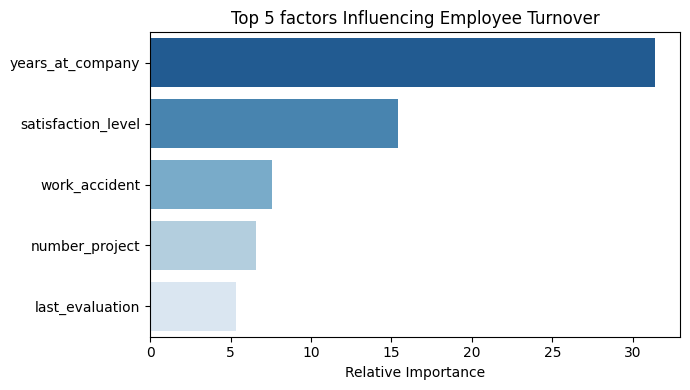

In [59]:
# getting feature importance with top 5 features

xm = xgb_cv.best_estimator_

importance = xm.get_booster().get_score(importance_type='gain')

importance_df = (
    pd.DataFrame(importance.items(), columns = ['feature', 'importance'])
    .sort_values('importance', ascending=False)
    .head(5)
)

plt.figure(figsize=(7,4))
sns.barplot(
    data=importance_df,
    x='importance',
    y='feature',
    palette='Blues_r'
)

plt.title('Top 5 factors Influencing Employee Turnover')
plt.xlabel('Relative Importance')
plt.ylabel('')
plt.tight_layout()
plt.show()